# Lab 10: Clustering with Scikit-Learn

The objective of this notebook is to learn about the **Scikit-Learn** library (<a href="https://scikit-learn.org/stable/" >official documentation</a>) and **clustering**. You can find a good guide at this <a href="https://www.w3schools.com/python/python_ml_k-means.asp" >link</a>.

You can find an **overview of all the available clustering algorithms in Scikit-Learn** <a href="https://scikit-learn.org/stable/modules/clustering.html" >here</a>.

## Outline

- [1. Load Dataset](#1)
- [2. K-Means](#2)
- [3. Hierarchical Clustering](#3)
- [4. DBScan](#4)
- [5. Chameleon clusters data](#5)


First, run the following cell to import some useful libraries to complete this Lab. If not already done, you must install them in your virtual environment

In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score

If the previous cell outputs one the following error: `ModuleNotFoundError: No module named 'sklearn'`, then, you have to install the Scikit-Learn package. If you don't remember how to install a Python package, please retrieve the guide on Anaconda-Navigator.

To install **sklearn** you can use one of the following commands from the terminal of your virtual environment: <br>
`pip install -U scikit-learn` <br>
`conda install -c intel scikit-learn`

<a id='1'></a>
## 1. Load dataset

### Exercise 1.1
Firstly, you will load the first dataset for this lab. Read the csv file from the following path `"data_lab5/lab5_data.csv"` into a DataFrame `df`. The separator of the csv file is the comma `,`. You should skip the header of the first row (i.e., skip the first row) and set the column names to the list stored in the variable `columns`.

<details>    
<summary>
    <font size="3" color="darkgreen"><b>Hints</b></font>
</summary>
<p>
<ul>
    <li>To read a csv file into a DataFrame, you can use pd.read_csv().</li>
    <li>To specify the <strong>separator</strong>, you can set the 'set' parameter.</li>
    <li>To specify the <strong>column names</strong>, you can set the 'names' parameter.</li>
    <li>To specify the <strong>number of rows to skip</strong>, you can set the 'skiprows' parameter.</li>
</ul>
</p>

In [3]:
columns = ['x', 'y', 'gt']

#### START CODE HERE (~1 line) ####
df = pd.read_csv("data_lab5/lab5_data.csv", sep=",", names=columns, skiprows=1)
#### END CODE HERE ####

df

,x,y,gt
0,516.012706,393.014514,0
1,436.211762,408.656585,0
2,512.052601,372.022014,0
3,489.140464,401.807159,0
4,446.207986,338.516682,0
...,...,...,...
331,638.916471,323.569096,1
332,542.005901,347.527070,0
333,611.964612,377.254978,0
334,520.654168,455.996453,0


#### Expected output
```                x	         y     gt```<br>
```0	516.012706	393.014514	0```<br>
```1	436.211762	408.656585	0```<br>
```2	512.052601	372.022014	0```<br>
```3	489.140464	401.807159	0```<br>
```4	446.207986	338.516682	0```<br>
```...	       ...	       ...    ...```<br>
```331	638.916471	323.569096	1```<br>
```332	542.005901	347.527070	0```<br>
```333	611.964612	377.254978	0```<br>
```334	520.654168	455.996453	0```<br>
```335	594.479314	392.901455	0```<br>
```336 rows × 3 columns```

The dataset is composed of the `x` and `y` coordinates for 336 points, and the True label in the column `gt`.
The next cell will create a DataFrame with the **input features** (i.e., all the `x` and `y` coordinates of the points) into a new DataFrame `df_X`, and a Series containing the **ground-truth labels** `gt_series`. Run the next cell to create the DataFrame and the Series. Notice that, in this case, we also have the **true labels**. Normally, when using clustering, the true labels are **not** available. 

In [4]:
df_X = df[["x","y"]].copy()
gt_series = df["gt"].copy()

The next cell defines a function that takes a DataFrames in input, and plots the scatter plot (i.e., the points) contained in the `x` and `y` columns. Run the next cell to define the function.

In [5]:
def plot_2d_scatter(df, title=""): 
    """Display a 2D scatter plot
    :param df: input data points, DataFrame ('x' and 'y' coordinates in the first and second column, respectively)
    :return: fig, ax, objects
    """
    fig, ax = plt.subplots(figsize=(6, 5), dpi=90) 
    ax.scatter(df.iloc[:,0], df.iloc[:,1])
    ax.set_xlabel("x", fontsize=14)
    ax.set_ylabel("y", fontsize=14)
    ax.set_title(title)
    ax.grid(True)
    return fig, ax # use them for further modifications

The next cell calls the previously defined function and **plots all the points in the input dataset in the plane**. All points are plotted with the same color because you still have not applied clustering. Run the next cell to plot all the points in the plane.

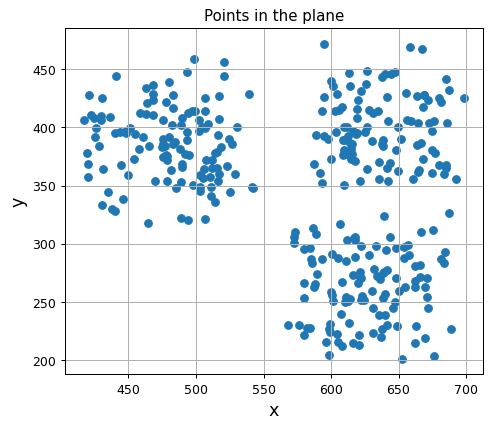

In [6]:
_, _ = plot_2d_scatter(df_X, "Points in the plane")

Notice that, with 2-dimensional data (like in this case), you can easily visualize the number of clusters because you can plot the points in a plane. In this case, it is reasonable to think that there are 3 distinct clusters. However, the procedure that we will apply in this notebook can also be applied with **higher dimensional data**, which is not visualizable in a plane. Therefore, for high dimensional data, it is challenging to visualize the correct number of clusters. You have to select the best number of clusters based on the analysis of the data.

The next cell defines a function that visualizes each cluster in a plane with a different color. It takes as parameters the points stored in a DataFrame `df` with the $x$ and $y$ coordinates of points stored in the `x` and `y` columns, respectively, the list with the predicted cluster id for each point `y_pred`, and an optional plot title `title`. Run the next cell to define the function.

In [7]:
def plot_2d_scatter_with_clusters(df, y_pred, title=""): 
    """Display a 2D scatter plot with each cluster with a different color
    :param df: input data points, DataFrame ('x' and 'y' coordinates in the 'x' and 'y' columns, respectively)
    :param y_pred: numpy array with the predicted label for each pointù
    :param title: string containing the title of the chart
    :return: fig, ax, objects
    """    
    fig, ax = plt.subplots(figsize=(6, 5), dpi=90) 
    ax.set_xlabel("x", fontsize=14)
    ax.set_ylabel("y", fontsize=14)
    
    n_clusters = list(set(y_pred)) 
    labels = [f"Cluster {c}" for c in n_clusters]
    
    for i, label in enumerate(n_clusters):
        
        if label == -1:
            label_name = "Outliers"
        else:
            label_name = labels[i]

        #add data points 
        ax.scatter(x=df.loc[y_pred==label, 'x'], 
                    y=df.loc[y_pred==label,'y'], 
                    alpha=0.7, label=label_name)
        
    ax.legend(loc=(1.1, 0.5))
    ax.set_title(title)
    ax.grid(True)
    
    return fig, ax # use them for further modifications

Firstly, we will plot the points with a different color based on the **ground-truth labels** present in the dataset. As discussed before, this dataset contains the true labels. However, the true labels are usually **not** available when performing clustering. We can see that there are **3 well-separated different clusters**. However, some **noise** is present in the clusters (i.e., some green points are closer to the blue cluster than to the green one, etc.). 

Run the next cell to plot the points based on the ground-truth.

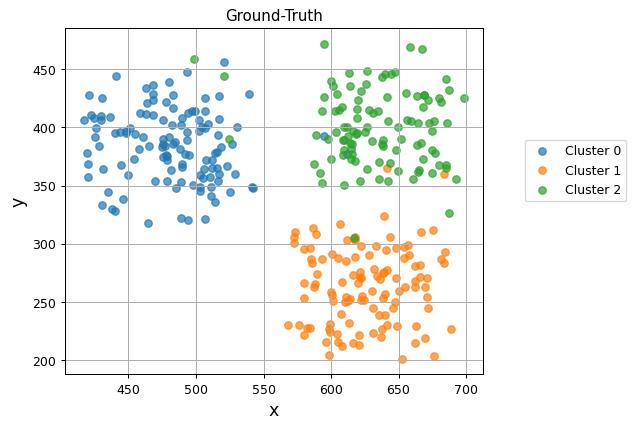

In [8]:
_, _ = plot_2d_scatter_with_clusters(df_X, gt_series, "Ground-Truth")

<a id='2'></a>
## 2. K-Means

### Exercise 2.1

We know from the ground-truth plot that the best number of clusters is 3. Now you will perform the **K-Means algorithm** with **3 as the number of clusters** $k$ to see if the algorithm can correctly identify the clusters. Create a **KMeans object** into a variable called `kmeans` with 3 as the number of clusters $k$ and the number of initialization equal to 10 with the `n_init` parameter (the n_init parameter specifies the number of times the k-means algorithm is run with different centroid seeds). Then, **fit** the KMeans algorithm and **predict** the cluster label for the input points stored in `df_X`. Store the predicted label in a new variable called `y_pred_kmeans`.

You can read the official documentation for the Scikit-Learn implementation of the K-Means algorithm <a href="https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html" >here</a>.

<details>    
<summary>
    <font size="3" color="darkgreen"><b>Hints</b></font>
</summary>
<p>
<ul>
    <li>You can specify the k value (i.e., number of clusters) for the K-Means algorithm with the 'n_clusters' parameter when creating the KMeans object.</li>
    <li>You can specify the number of initialization for the centroid with the 'n_init' parameter when creating the KMeans object.</li>
</ul>
</p>

In [9]:
#### START CODE HERE (~2 lines) ####
kmeans = KMeans(n_clusters=3, n_init=10)
y_pred_kmeans = kmeans.fit_predict(df_X)
#### END CODE HERE ####

Now, run the next cell to visualize the predicted clusters in the plane.

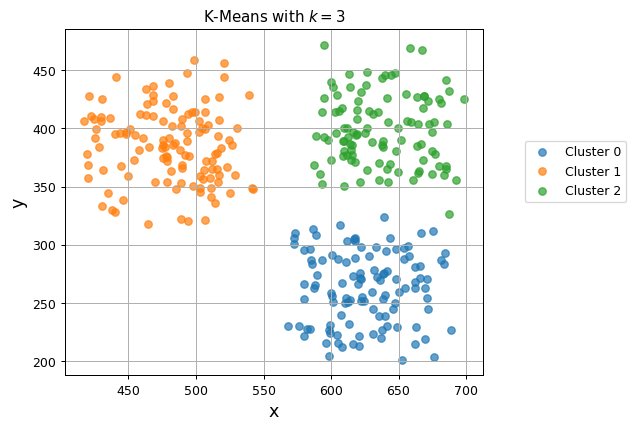

In [10]:
_, _ = plot_2d_scatter_with_clusters(df_X, y_pred_kmeans, "K-Means with $k=3$")

The chart shows that the algorithm, with this data, can correctly identify the 3 clusters.

### Exercise 2.2
Often, you cannot visualize the results of the clustering algorithm graphically because the input features can be **high-dimensional**. Moreover, usually, the **true labels are not available** when performing clustering (i.e., **unsupervised learning**). Now, you will **evaluate the performance** of the K-Means algorithm with $k=3$ with the **silhouette** metric.

**Compute** the **average silhouette** for the cluster division with $k=3$ into a variable `silh_avg`. Then, **print** the silhouette value. Remember, the silhouette is a score in the range [-1, 1] that measures the **cohesion** and the **separation** of clusters (i.e., points within the same cluster must be very cohesive with each other and well separated from points in other clusters). The higher the value, the better the cluster. You can learn more about **silhouette** <a href="https://tushar-joshi-89.medium.com/silhouette-score-a9f7d8d78f29" >here</a> and <a href="https://towardsdatascience.com/silhouette-coefficient-validating-clustering-techniques-e976bb81d10c" >here</a>.

<details>    
<summary>
    <font size="3" color="darkgreen"><b>Hints</b></font>
</summary>
<p>
<ul>
    <li>To compute the average silhouette you can use the 'silhouette_score' function of the Scikit-Learn library <a href="https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html" >link</a>.</li>
    <li>You have to specify the points (e.g., the dataframe) and the predicted cluster labels.</li>
</ul>
</p>

In [11]:
#### START CODE HERE (~2 lines) ####
silh_avg = silhouette_score(df_X, y_pred_kmeans)
print(silh_avg)
#### END CODE HERE ####

0.6112689520666093


#### Expected output
```0.6112689520666093```

The silhouette value shows that K-Means algorithm with $k=3$ performs well with a value that is approximately 0.61.

### Exercise 2.3
Now, you will **evaluate the predicted clusters with respect to the true labels**. Again, usually, the true labels are **not** available. Therefore, you cannot evaluate the clustering algorithm with the true labels. However, the true labels can be available to some datasets used to evaluate **new** clustering algorithms (e.g., if you want to propose a new clustering algorithm). As a **quantitative evaluation metric** you can use the **rand index**. You can learn more about **rand index** <a href="https://www.statology.org/rand-index/" >here</a>.

The Rand index always takes on a value between 0 and 1, where 0 indicates that two clustering methods do not agree on the clustering of any pair of elements, and 1 indicates that two clustering methods perfectly agree on the clustering of every pair of elements (i.e., the higher the value, the better the performance of the algorithm).


Now, **compute** and **print** the **rand index** of the predicted cluster labels and the true labels. Remember that the true labels are stored in the `gt_series` variable.
<details>    
<summary>
    <font size="3" color="darkgreen"><b>Hints</b></font>
</summary>
<p>
<ul>
    <li>To compute the average rand index you can use the 'adjusted_rand_score' function of the Scikit-Learn library <a href="https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_rand_score.html" >link</a>.</li>
    <li>You have to specify the true labels (e.g., the series or the list with the true labels) and the predicted cluster labels.</li>
</ul>
</p>

In [12]:
#### START CODE HERE (~2 lines) ####
ars = adjusted_rand_score(gt_series, y_pred_kmeans)
print(ars)
#### END CODE HERE ####

0.9308764986695224


#### Expected output
```0.9308764986695224```

The rand index value shows that K-Means algorithm with $k=3$ performs well. It correctly assigns most of the cluster labels.

### Exercise 2.4

Can we identify the best number of clusters $k$ without visualizing the ground-truth or the points in a plane? 

As discussed before, ground-truth labels are usually **not** available. Moreover, clustering can also be performed with high dimensional data where you can not visualize the samples in a plane (i.e., identifying the number of clusters just by visualizing it will be difficult).

Now you will perform the KMeans algorithm for **different values of** $k \in [2, 10]$. Then, you will **visualize** and **evaluate** each $k$ division to select the best $k$ with the **silhouette score** and the **cluster charts**.

Implement a loop for each value of $k$ from `min_k` to `max_k` (both included). Then, for each value of $k$ (i.e., each iteration) create a KMeans object with the current number of clusters and the parameter `n_init` equal to 10. Predict the cluster labels for the points stored in `df_X` with the current $k$ (i.e., using the current kmeans object). Append to `y_pred_list` the predicted cluster labels for the current $k$. Compute the current silhouette and append it to `silh_list`.

You can read the official documentation for the Scikit-Learn implementation of the K-Means algorithm <a href="https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html" >here</a>.

Replace `None` with your code.

In [13]:
min_k = 2 # Starting from 2 clusters
max_k = 10 # Until 10 clusters

silh_list = [] # List of avg silouhette values for each cluster division (k)
inertia_list = [] # List of inertia values for each cluster division (k)
y_pred_list = [] # list of numpy arrays containing the predicted clusters labels for each k

#### START CODE (~6 lines) HERE ####
for k in range(min_k, max_k+1): # Define a loop for each k in [2, 10] (both included)
    kmeans_k = KMeans(n_clusters=k, n_init=10) # Create the K-Means object with current k
    y_pred_kmeans_k = kmeans_k.fit_predict(df_X) # Predict the cluster labels with current k
    
    y_pred_list.append(y_pred_kmeans_k) # Append the list of predicted cluster labels 
    
    silh_avg_k = silhouette_score(df_X, y_pred_kmeans_k) # Compute the average silhouette for current k
    silh_list.append(silh_avg_k) # Append the average silhoette
    inertia_list.append(kmeans_k.inertia_) # Append the inertia value
#### END CODE HERE ####

The next cell visualizes the plots of all the $k$ values

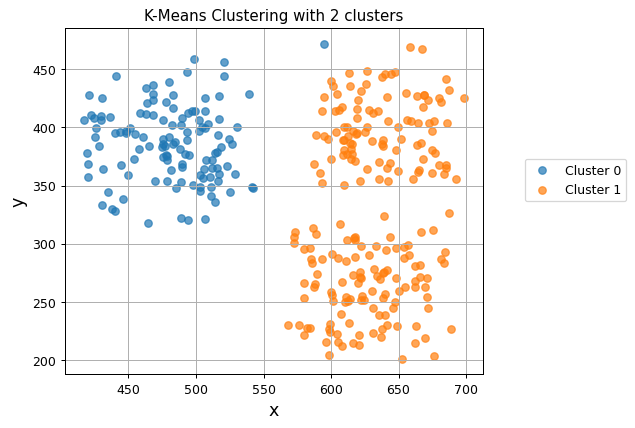

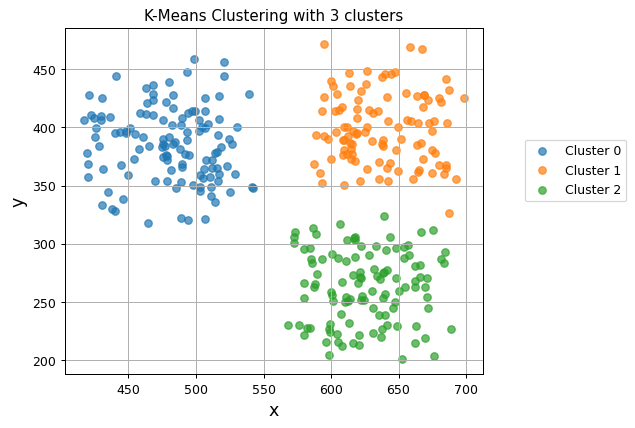

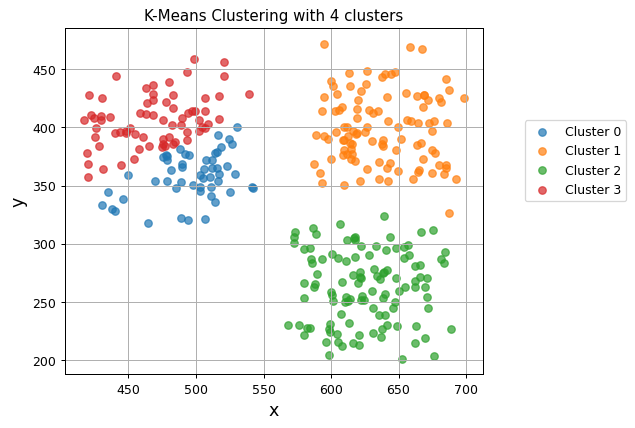

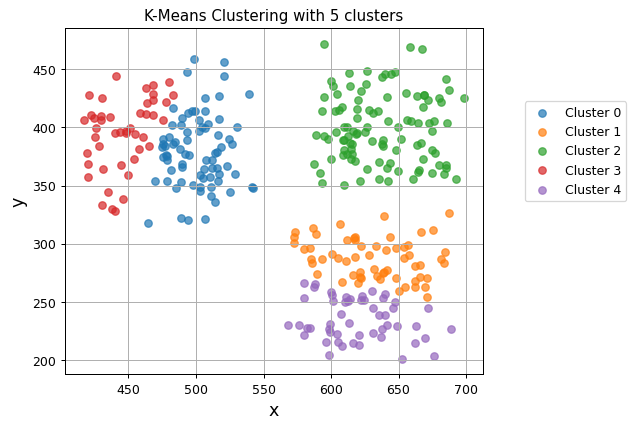

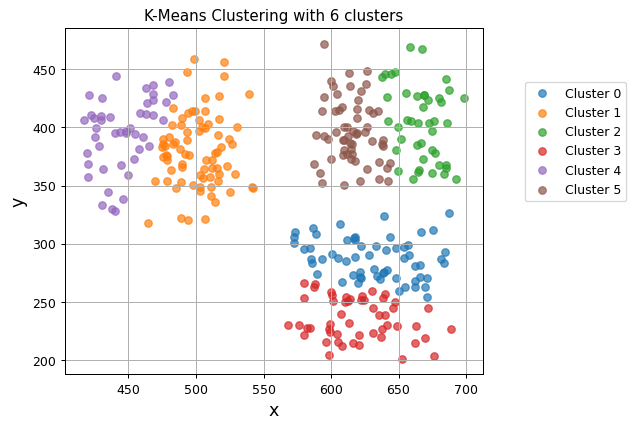

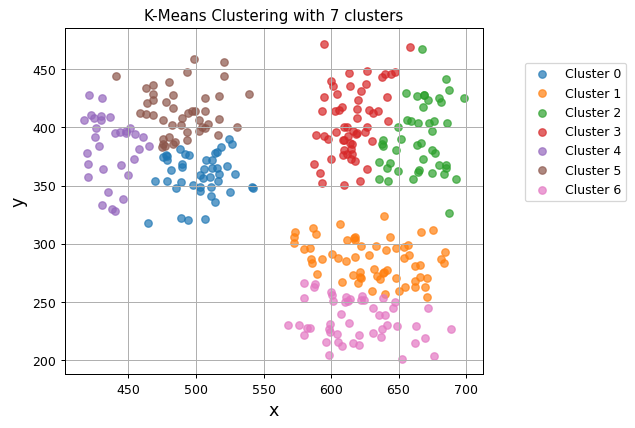

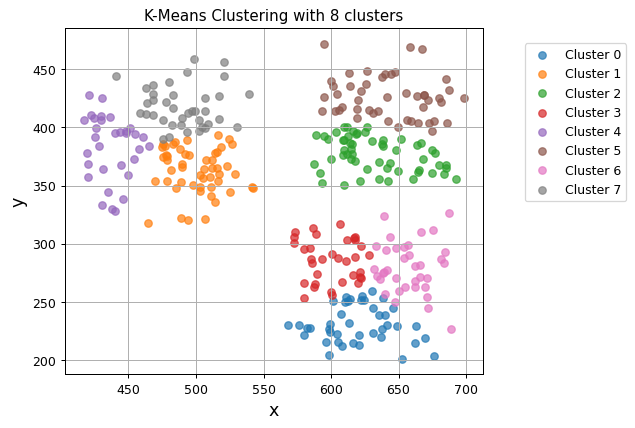

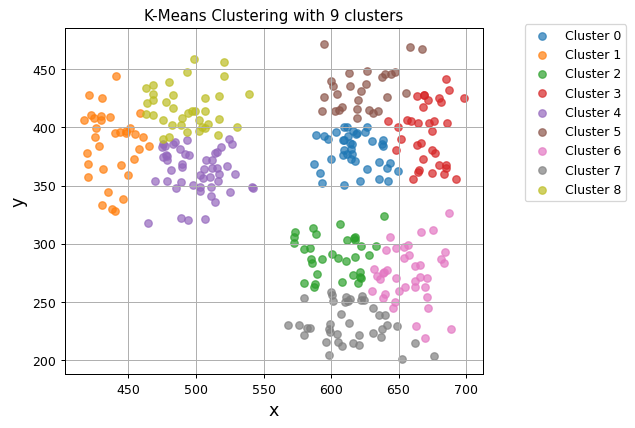

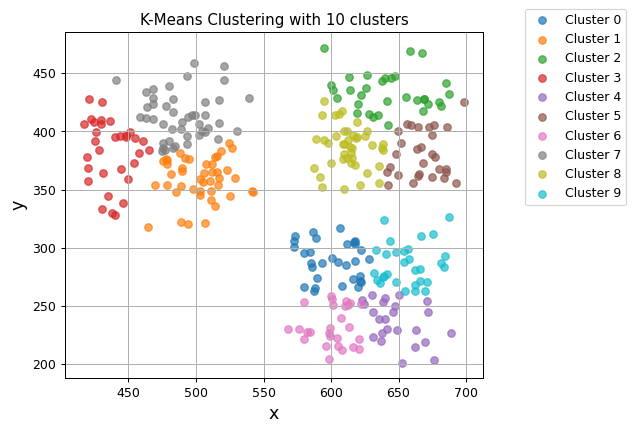

In [14]:
for k in range(min_k, max_k+1):
    _, _ = plot_2d_scatter_with_clusters(df_X, y_pred_list[k-min_k], f"K-Means Clustering with {k} clusters")

What do you think is the best k-value? Why?

In [15]:
#### START ANSWER HERE ####

#### END ANSWER HERE ####

Now, you will plot the average silhouette value for each $k$ value analyzed. Please, run the next cell to visualize the plot.

Text(0.5, 0.98, 'K-Means Clustering: Silhouette and Inertia')

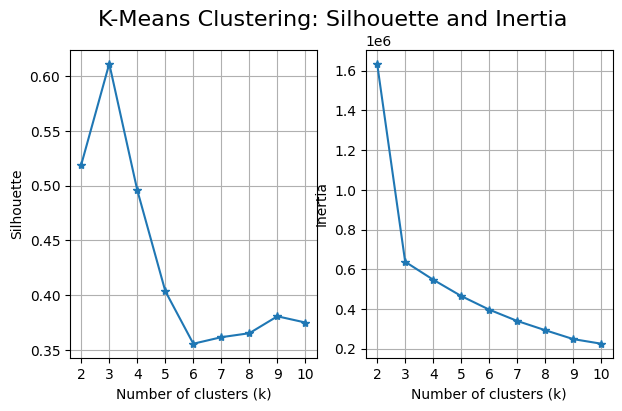

In [16]:
fig, ax = plt.subplots(figsize=(7, 4),ncols=2)
x = range(len(silh_list))
x_ticks = range(min_k, max_k+1)

ax[0].plot(x, silh_list, marker='*')
ax[0].set_xticks(x, x_ticks)
ax[0].set_xlabel("Number of clusters (k)")
ax[0].set_ylabel("Silhouette")
ax[0].grid(True)


ax[1].plot(x, inertia_list, marker='*')
ax[1].set_xticks(x, x_ticks)
ax[1].set_xlabel("Number of clusters (k)")
ax[1].set_ylabel("Inertia")
ax[1].grid(True)
fig.suptitle("K-Means Clustering: Silhouette and Inertia", fontsize=16)

From this silhouette graph, what do you think is the best k-value? Has your answer changed since before?

In [17]:
#### START ANSWER HERE ####

#### END ANSWER HERE ####

<a id='3'></a>
## 3. Hierarchical Clustering

Here, is already provided to you the code to run the **Hierarchical clustering**. Run the next cells to perform the hierarchical clustering. The dendrogram of the hierarchical clustering is automatically cut to match the `n_clusters` specified. You can read the documentation of the agglomerative clustering <a href="https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html" >here</a>.

In [18]:
n_clusters = 3
hc = AgglomerativeClustering(n_clusters)
y_pred_hc = hc.fit_predict(df_X)

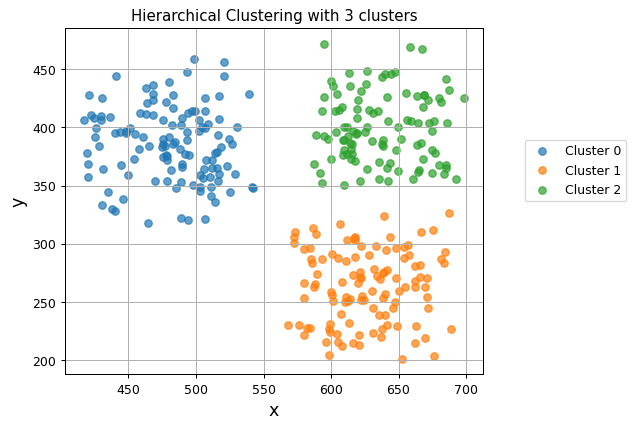

In [19]:
_, _ = plot_2d_scatter_with_clusters(df_X, y_pred_hc, f"Hierarchical Clustering with {n_clusters} clusters")

In [20]:
silh_avg_hc = silhouette_score(df_X, y_pred_hc)
print(silh_avg_hc)

0.6110715619378334


You can see that the result is practically the same.

<a id='4'></a>
## 4. DBScan

Here, is already provided to you the code to run the **Density-based clustering (dbscan)**. Run the next cells to perform the dbscan clustering. The dbscan does not require the specification of the number of clusters. Moreover, it also identifies the outliers. However, it require the specification of two parameters: epsilon and the minimum number of points that are often difficult to set. You can read the documentation of the dbscan clustering <a href="https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html" >here</a>.

In [21]:
dbscan = DBSCAN(eps=20, min_samples=10)

In [22]:
y_pred_dbscan= dbscan.fit_predict(df_X)

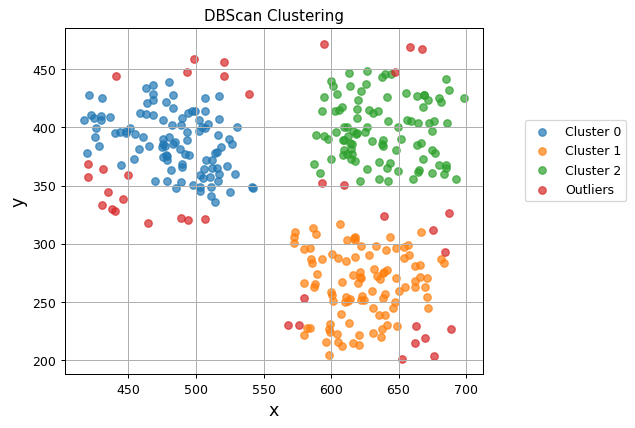

In [23]:
_, _ = plot_2d_scatter_with_clusters(df_X, y_pred_dbscan, "DBScan Clustering")

The red points are the outliers.

<a id='5'></a>
## 5. Chameleon clusters data

Now, you will move to another dataset, the `chameleon_clusters` data. This time the true labels are not available.
The next cell loads the data into a DataFrame `df_X_cc`. Please run the next cell to load the data.

In [25]:
df_X_cc = pd.read_csv("data_lab5/chameleon_clusters.csv", sep=",")
df_X_cc

,x,y
0,68.601997,102.491997
1,454.665985,264.808990
2,101.283997,169.285995
3,372.614990,263.140991
4,300.989014,46.555000
...,...,...
7995,442.420990,303.721985
7996,495.451996,288.502991
7997,267.605011,141.725006
7998,238.358002,252.729996


Run the next cell to plot the points in the plane.

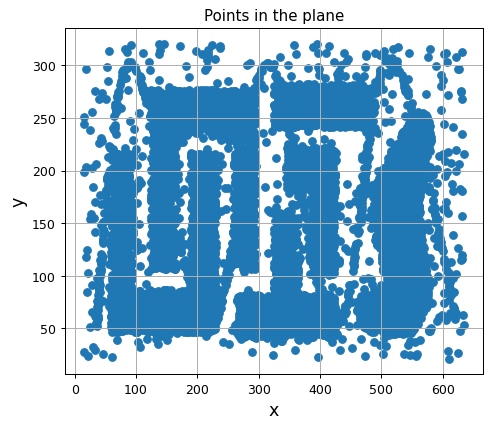

In [26]:
_, _ = plot_2d_scatter(df_X_cc, "Points in the plane")

You can see that this time the points are distributed in a more complicated manner. It is also more difficult to identify the best number of clusters. In addition, there are many points that are outliers.

### Exercise 5.1

Now, you will implement the same loop as for exercise 2.4. The loop iterates over different values of $k$ from `min_k` to `max_k`. For each $k$ value (i.e., each iteration) create a KMeans object with the current number of clusters and the parameter `n_init` equal to 10. Predict the cluster labels for the points stored in `df_X_cc` with the current $k$ (i.e., using the current kmeans object). Append to `y_pred_list` the predicted cluster labels for the current $k$. Compute the current silhouette and append it to `silh_list`.

You can read the official documentation for the Scikit-Learn implementation of the K-Means algorithm <a href="https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html" >here</a>.

Replace `None` with your code.

In [28]:
min_k = 2 # Starting from 2 clusters
max_k = 10 # Until 10 clusters
silh_list = [] # List of avg silouhette values for each cluster division (k)
y_pred_list = [] # list of numpy arrays containing the predicted clusters labels for each k

#### START CODE (~6 lines) HERE ####
for k in range(min_k, max_k+1): # Define a loop for each k in [min_k, max_k]
    kmeans_k = KMeans(n_clusters=k, n_init=10) # Define the kmeans object with current k and n_init = 10
    y_pred_kmeans_k = kmeans_k.fit_predict(df_X_cc) # Predict the cluster labels with current k
    
    y_pred_list.append(y_pred_kmeans_k) # Append the predicted labels to the list of predictions
    
    silh_avg_k = silhouette_score(df_X_cc, y_pred_kmeans_k) # Compute the average silhouette for the current k
    silh_list.append(silh_avg_k) # Append the current average silhouette to the list of silhouette values
#### END CODE HERE ####

The next cell visualizes the clusters plots of all the $k$ values.

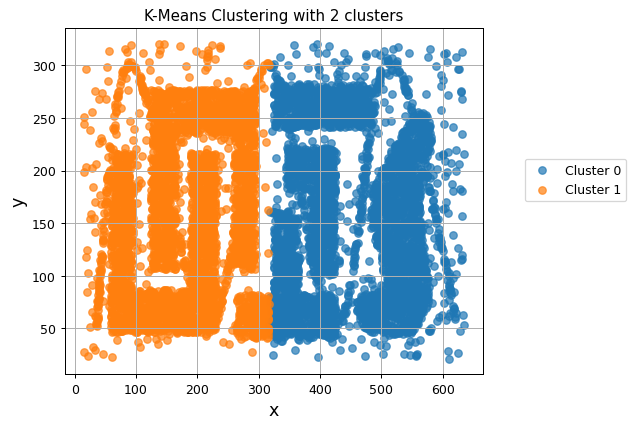

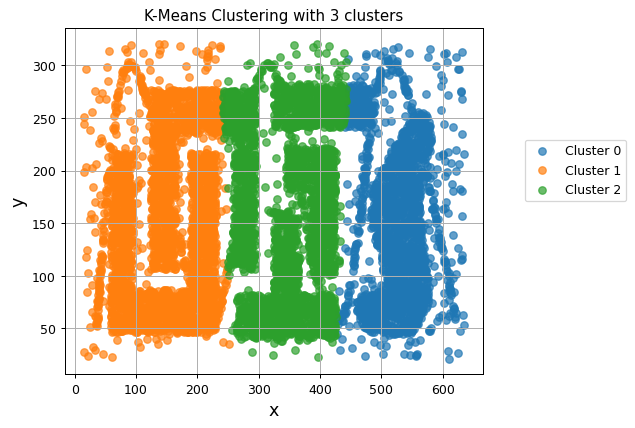

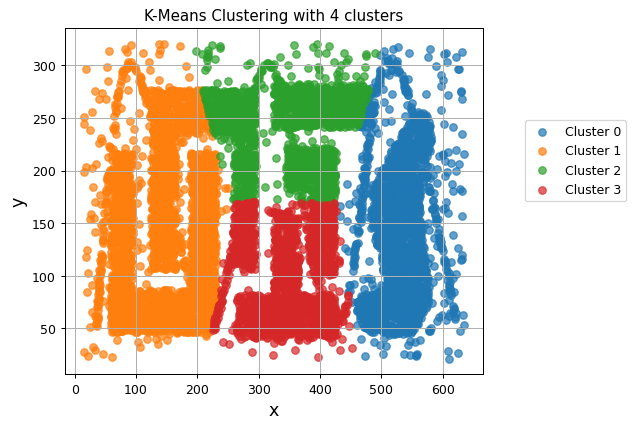

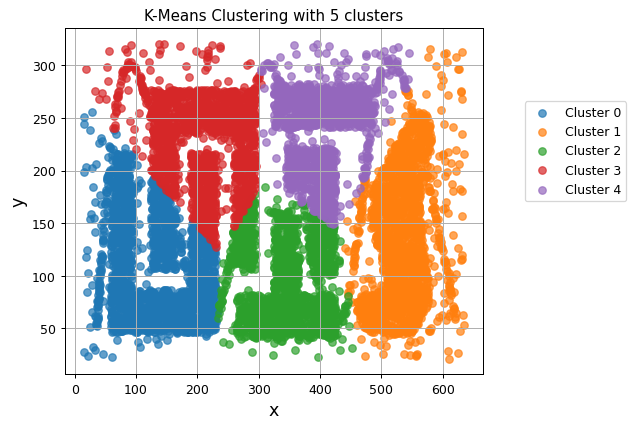

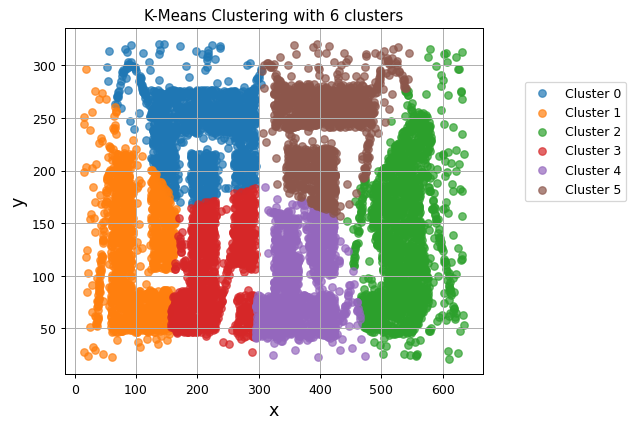

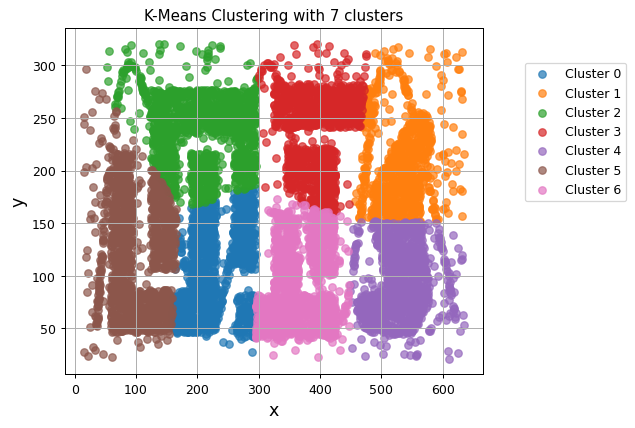

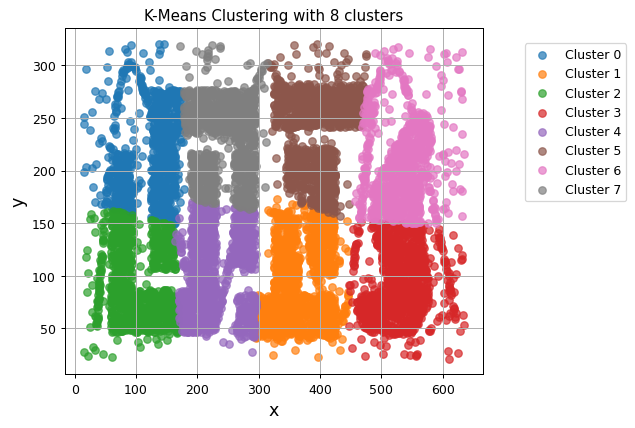

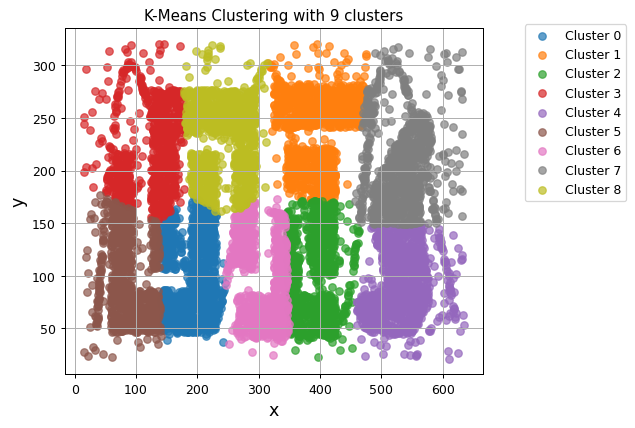

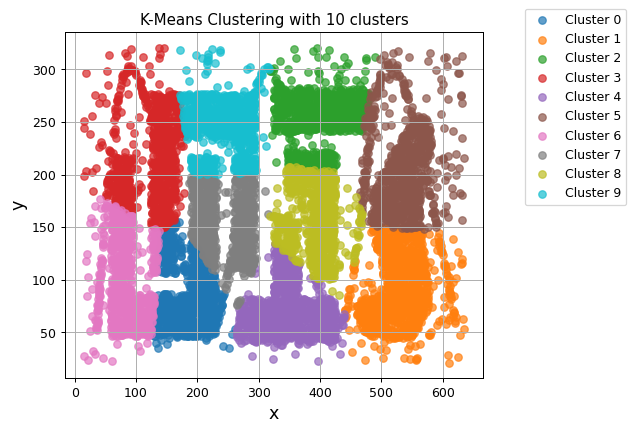

In [42]:
for k in range(min_k, max_k+1):
    _, _ = plot_2d_scatter_with_clusters(df_X_cc, y_pred_list[k-min_k], f"K-Means Clustering with {k} clusters")

In this case, KMeans performs worse. In fact, it fails to detect clusters correctly. You can see that it tends to form spherical clusters. Moreover, it is not suitable for clusters and points with different densities.

Now, you will plot the average silhouette value for each $k$ value analyzed. Please, run the next cell to visualize the plot.

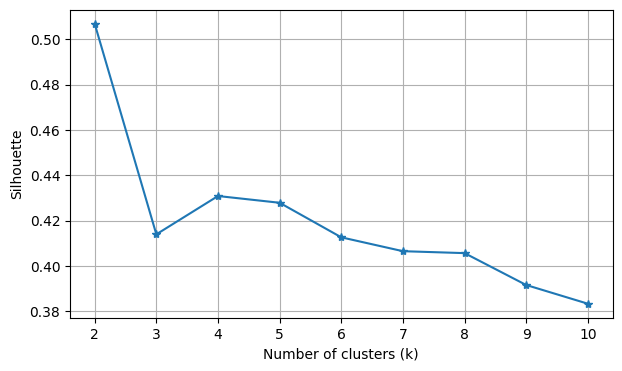

In [30]:
fig, ax = plt.subplots(figsize=(7, 4))
x = range(len(silh_list))
x_ticks = range(min_k, max_k+1)

ax.plot(x, silh_list, marker='*')
ax.set_xticks(x, x_ticks)
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Silhouette")
ax.grid(True)

From the silhouette graph, the best k-number seems to be 2. However, we can visually see that it is not very effective.

### Exercise 5.2

For this type of data with different densities, **dbscan** may be a better choice. Perform the clustering with the **dbscan** algorithm for the data stored in `df_X_cc`. Store the predicted labels in a variable `y_pred_dbscan`. Set the parameters of the DBSCAN object as follows: `eps`=10 and `min_samples`=20. Go ahead and try changing the values to see how the results change. You can read the documentation of the dbscan clustering <a href="https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html" >here</a>.

In [31]:
#### START CODE HERE (~2 lines) ####
dbscan = DBSCAN(eps=10, min_samples=20)
y_pred_dbscan = dbscan.fit_predict(df_X_cc)
#### END CODE HERE ####

Now, run the next cell to plot the results.

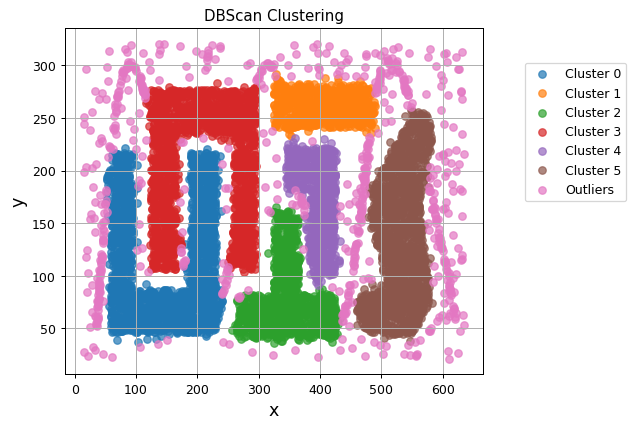

In [32]:
_, _ = plot_2d_scatter_with_clusters(df_X_cc, y_pred_dbscan, "DBScan Clustering")

Graphically, you can see that the DBScan seems to perform much better in this case. It can identify clusters of points and also outliers.